In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

In [2]:
#coffea output file
f_sig = "../coffea/new_signal_2022/match_new.coffea"
#Nested Dictionary:
sig_histo = util.load(f_sig) [0]
# sig_histo["match_ele_pt"]
# # key = sig_histo.keys()
# # for i in key:
# #     print (i)

Saved: ./plots/signal_2022/gen_ele_pt.png


array([1106., 1598., 3124., 3085., 2419., 1832., 1338.,  995.,  671.,
        445.,  288.,  214.,  137.,   98.,   62.,  117.,   31.,    8.])

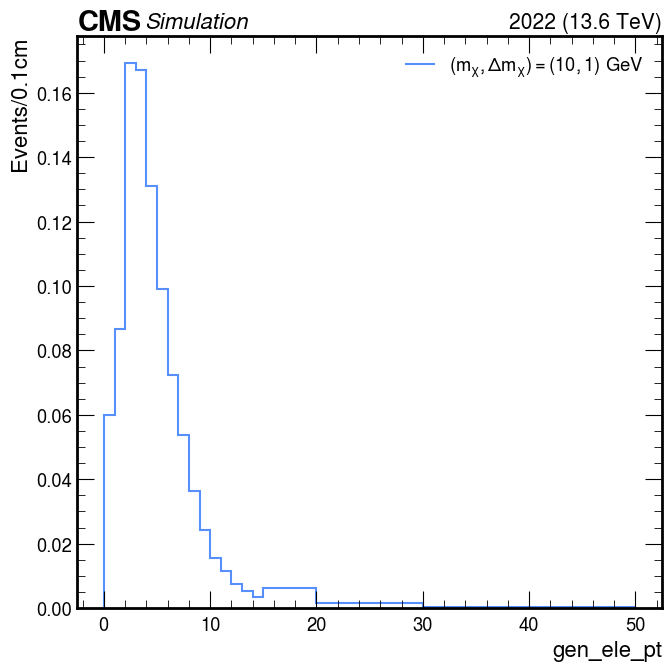

In [4]:
#Denominator: gen_ele_pt 
fig, ax = plt.subplots(figsize=(7,7))

m1=10
delta = 0.1
ctau = 10

# Plot settings
plot_dict = {
    'variable': 'gen_ele_pt',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': 1j,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    'xlabel': "gen_ele_pt",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': 'Events/0.1cm',   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2022',
    'outName': f'gen_ele_pt.png'
}

deno_count, deno_histo = ptools.plot_signal_1D_match(sig_histo, m1, delta, ctau, plot_dict, style_dict)
deno_count


Saved: ./plots//match_ele_pt_R_passID.png
[ 98. 108. 246. 332. 321. 655. 594. 487. 346. 269. 166. 120.  84.  69.
  51.  27.  22.  32.  10.   4.   8.   6.   3.   2.   3.   5.   0.   2.
   4.   0.   3.   0.   0.   1.   1.   0.   0.   0.   1.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.]


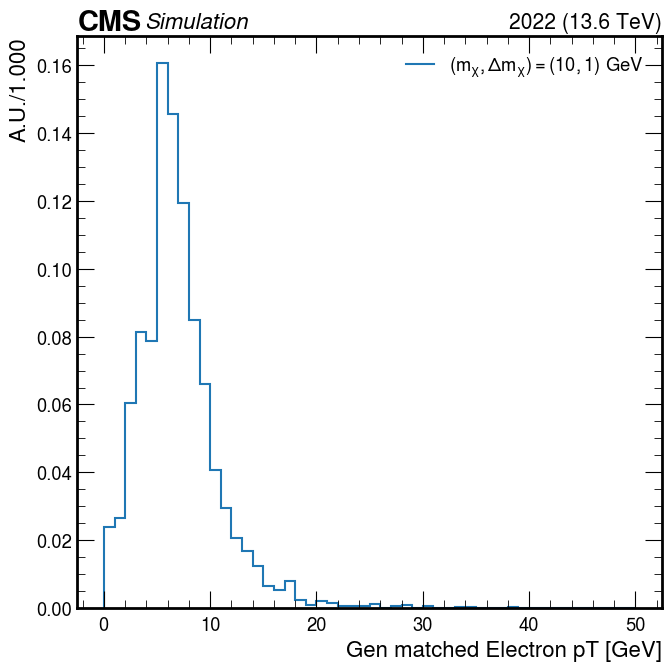

In [11]:
fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {'variable': 'match_ele_gen_pt', 'cut': 'cut1', 'year': 2022}
style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': 1j,
    'doLogy': False,
    'doLogx': False,
    'doDensity': True,
    'xlabel': "Gen matched Electron pT [GeV]",
    'ylabel': None,
    'doSave': True,
    'outDir': './plots/',
    'outName': 'match_ele_pt_R_passID.png'
}

num_count, num_histo = ptools.plot_signal_1D(
    sig_histo,
    m1=10,
    delta=0.1,
    ctau=10,
    plot_dict=plot_dict,
    style_dict=style_dict,
    match_type='R',  # GED electrons
    passID=1        # Only electrons that pass ID
)

print (num_count)

In [6]:
print ("Numerator:", num_count)
print (len(num_count))
print ("Denominator:", deno_count)
print (len(deno_count))

Numerator: [ 98. 108. 246. 332. 321. 655. 594. 487. 346. 269. 166. 120.  84.  69.
  51.  27.  22.  32.  10.   4.   8.   6.   3.   2.   3.   5.   0.   2.
   4.   0.   3.   0.   0.   1.   1.   0.   0.   0.   1.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.]
50
Denominator: [1.106e+03 1.598e+03 3.124e+03 3.085e+03 2.419e+03 1.832e+03 1.338e+03
 9.950e+02 6.710e+02 4.450e+02 2.880e+02 2.140e+02 1.370e+02 9.800e+01
 6.200e+01 4.000e+01 2.400e+01 3.300e+01 1.400e+01 6.000e+00 5.000e+00
 5.000e+00 3.000e+00 4.000e+00 4.000e+00 4.000e+00 2.000e+00 2.000e+00
 2.000e+00 0.000e+00 2.000e+00 0.000e+00 1.000e+00 1.000e+00 2.000e+00
 0.000e+00 0.000e+00 0.000e+00 1.000e+00 1.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00]
50


In [7]:
index_removal = []
for (index, value) in enumerate(deno_count):
    if (value == 0):
        index_removal.append(index)

print (index_removal)
den = np.delete(deno_count, index_removal)


num = np.delete(num_count, index_removal)
print ("num:",num)
print ("den:", den)

y= np.divide(num,den)
print ("Efficiency=",y)

bins = np.linspace(0, 50, 50)
bin_x = np.delete(bins, index_removal)
print("bin_x:", bin_x)

[29, 31, 35, 36, 37, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
num: [ 98. 108. 246. 332. 321. 655. 594. 487. 346. 269. 166. 120.  84.  69.
  51.  27.  22.  32.  10.   4.   8.   6.   3.   2.   3.   5.   0.   2.
   4.   3.   0.   1.   1.   1.   0.]
den: [1.106e+03 1.598e+03 3.124e+03 3.085e+03 2.419e+03 1.832e+03 1.338e+03
 9.950e+02 6.710e+02 4.450e+02 2.880e+02 2.140e+02 1.370e+02 9.800e+01
 6.200e+01 4.000e+01 2.400e+01 3.300e+01 1.400e+01 6.000e+00 5.000e+00
 5.000e+00 3.000e+00 4.000e+00 4.000e+00 4.000e+00 2.000e+00 2.000e+00
 2.000e+00 2.000e+00 1.000e+00 1.000e+00 2.000e+00 1.000e+00 1.000e+00]
Efficiency= [0.08860759 0.06758448 0.0787452  0.1076175  0.13269946 0.35753275
 0.44394619 0.48944724 0.51564829 0.60449438 0.57638889 0.56074766
 0.61313869 0.70408163 0.82258065 0.675      0.91666667 0.96969697
 0.71428571 0.66666667 1.6        1.2        1.         0.5
 0.75       1.25       0.         1.         2.         1.5
 0.         1.         0.5        1.         0.        ]
bin_

In [8]:
y = np.divide(num,den)
print (len(y))
len(bin_x)

35


35

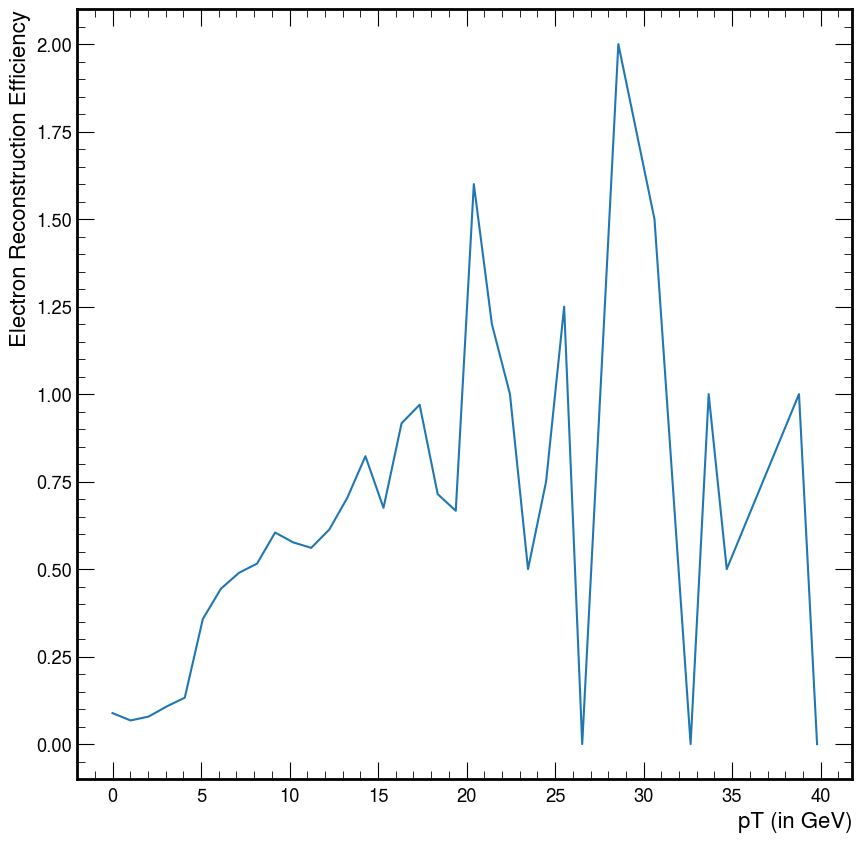

In [9]:
plt.plot(bin_x, y)
plt.xlabel("pT (in GeV)")
plt.ylabel("Electron Reconstruction Efficiency")
plt.savefig("Electron_eff_latest.png")